In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns


%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
sixteen_offices = pd.read_csv("./data/116_Office_Numbers")
seventeen_offices = pd.read_csv("./data/117_Office_Numbers")
eightteen_offices = pd.read_csv("./data/118_Office_Numbers")

In [3]:
combined_offices = pd.concat([sixteen_offices, seventeen_offices, eightteen_offices], axis=0, ignore_index=True)

In [4]:
sixteen_scores = pd.read_csv("./data/116_CEL_House.csv")
seventeen_scores = pd.read_csv("./data/117_CEL_House.csv")
eightteen_scores = pd.read_csv("./data/118_CEL_House.csv")

In [5]:
combined_scores = pd.concat([sixteen_scores, seventeen_scores, eightteen_scores], axis=0, ignore_index=True)
combined_scores.rename(columns={'Legislator name, as given in THOMAS': 'Full_Name'}, inplace=True)
combined_scores.rename(columns={'Benchmark score (Classic) based on majority, seniority, chairs': 'Benchmark'}, inplace=True)
combined_scores.rename(columns={'LES 1.0': 'LES_1.0'}, inplace=True)
combined_scores.rename(columns={'LES/benchmark (Classic)': 'LES/Benchmark'}, inplace=True)

In [6]:
combined_offices = pd.merge(combined_offices, combined_scores[['Full_Name', 'LES_1.0']], 
                                    on='Full_Name', how='inner')

In [7]:
combined_offices = pd.merge(combined_offices, combined_scores[['Full_Name', 'Benchmark']], 
                                    on='Full_Name', how='inner')

In [8]:
combined_offices = pd.merge(combined_offices, combined_scores[['Full_Name', 'LES/Benchmark']], 
                                    on='Full_Name', how='inner')

In [9]:
freshman_combined_offices = (
    combined_offices[combined_offices["Freshman"] == "yes"]
    .copy()
)

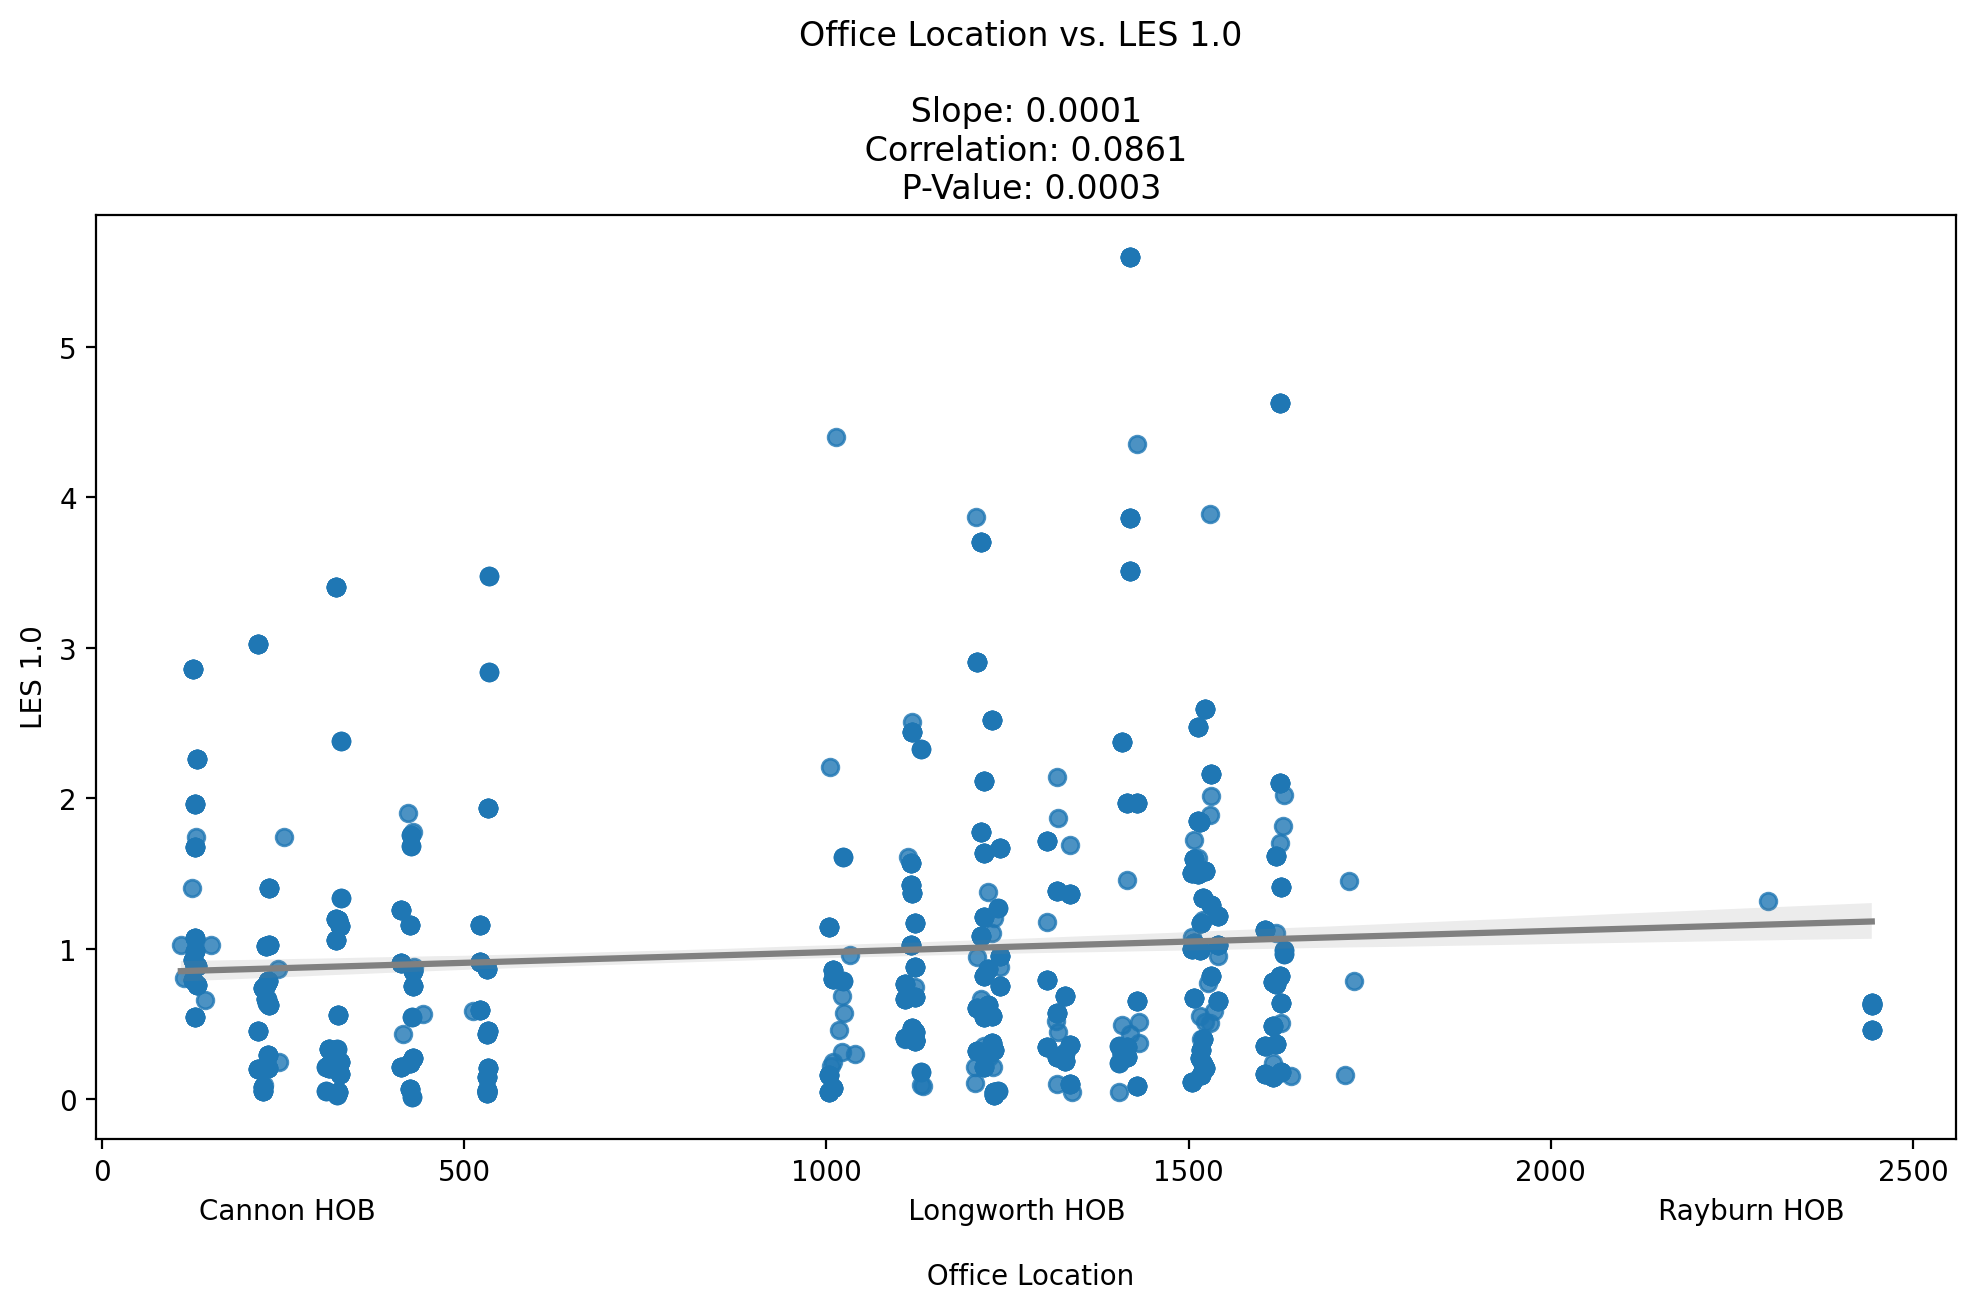

In [10]:
#Scatterchart without trend line

#freshman_combined_offices.plot.scatter(x="Number", y="LES_1.0", figsize=(7, 5))
#plt.title("Office Location vs. LES 1.0")
#plt.xlabel("Office Location")
#plt.ylabel("LES 1.0");
#plt.savefig('my_graph.png', dpi=300, bbox_inches='tight') 

freshman_combined_offices_drop_na = freshman_combined_offices[['Number', 'LES_1.0']].dropna()

slope, intercept = np.polyfit(freshman_combined_offices_drop_na['Number'], freshman_combined_offices_drop_na['LES_1.0'], 1)

#print(f"The slope is: {slope}")


Correlation = freshman_combined_offices['Number'].corr(freshman_combined_offices['LES_1.0'])


clean_df = freshman_combined_offices[['Number', 'LES_1.0']].dropna()

corr_coef, p_value = stats.pearsonr(clean_df['Number'], clean_df['LES_1.0'])

#print(f"P-value: {p_value}")




plt.figure(figsize=(12, 6))
sns.regplot(data=freshman_combined_offices, x='Number', y='LES_1.0', line_kws={"color": "grey"})
plt.title(f"Office Location vs. LES 1.0 \n \n Slope: {round(slope, 4)} \n Correlation: {round(Correlation, 4)} \n P-Value: {round(p_value, 4)}")
plt.xlabel("Cannon HOB                                                            Longworth HOB                                                            Rayburn HOB \n \n Office Location")
plt.ylabel("LES 1.0");
plt.savefig("Office Location vs LES.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
freshman_combined_offices_cannon_only = (
    freshman_combined_offices[freshman_combined_offices["Building"] == "CHOB"]
    .copy()
)

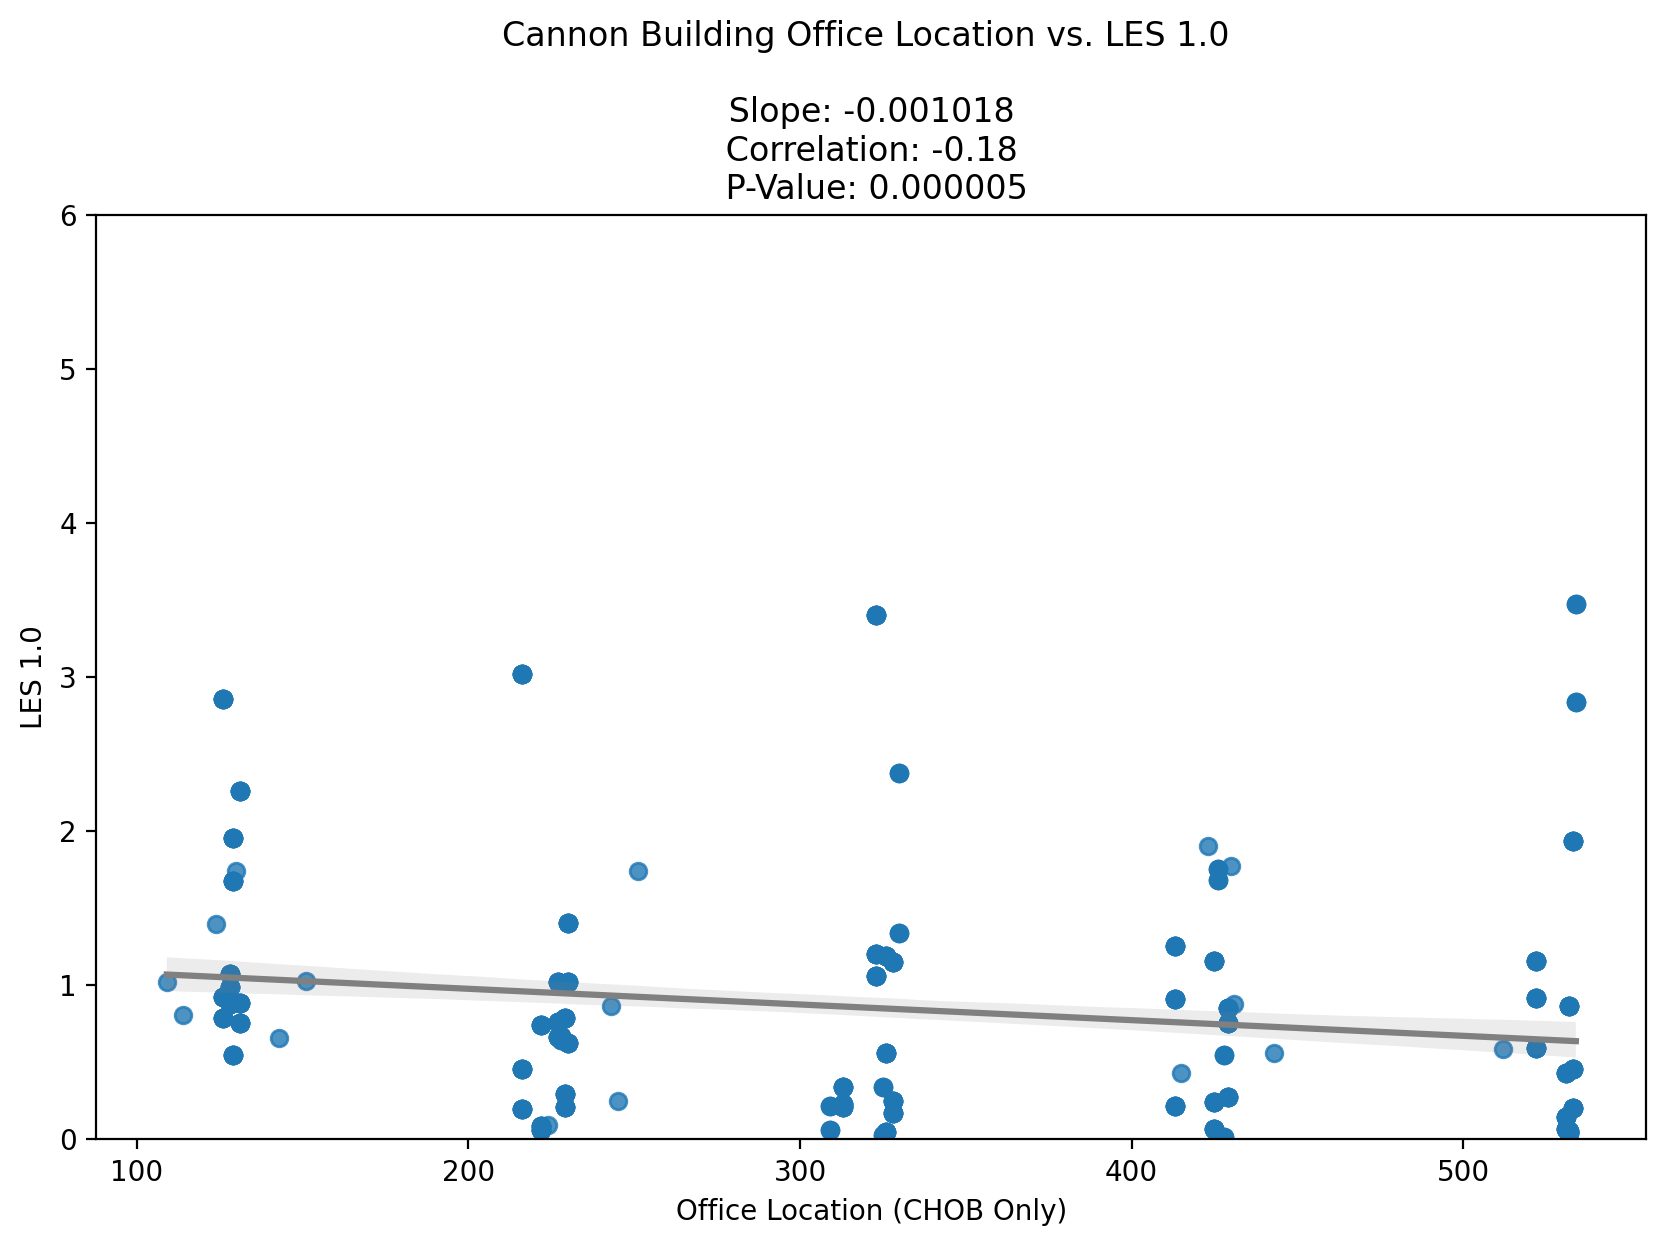

In [12]:
freshman_combined_offices_cannon_only_drop_na = freshman_combined_offices_cannon_only[['Number', 'LES_1.0']].dropna()

slope, intercept = np.polyfit(freshman_combined_offices_cannon_only_drop_na['Number'], freshman_combined_offices_cannon_only_drop_na['LES_1.0'], 1)

#print(f"The slope is: {slope}")


Correlation = freshman_combined_offices_cannon_only['Number'].corr(freshman_combined_offices_cannon_only['LES_1.0'])


clean_df = freshman_combined_offices_cannon_only[['Number', 'LES_1.0']].dropna()

corr_coef, p_value = stats.pearsonr(clean_df['Number'], clean_df['LES_1.0'])

#print(f"P-value: {p_value}")




plt.figure(figsize=(10, 6))
sns.regplot(data=freshman_combined_offices_cannon_only, x='Number', y='LES_1.0', line_kws={"color": "grey"})
plt.title(f"Cannon Building Office Location vs. LES 1.0 \n \n Slope: {round(slope, 6)} \n Correlation: {round(Correlation, 2)} \n P-Value: 0.000005")
plt.xlabel("Office Location (CHOB Only)")
plt.ylabel("LES 1.0");
plt.ylim(0, 6)
plt.savefig("Cannon Building Office Location vs LES.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
freshman_combined_offices_longworth_only = (
    freshman_combined_offices[freshman_combined_offices["Building"] == "LHOB"]
    .copy()
)

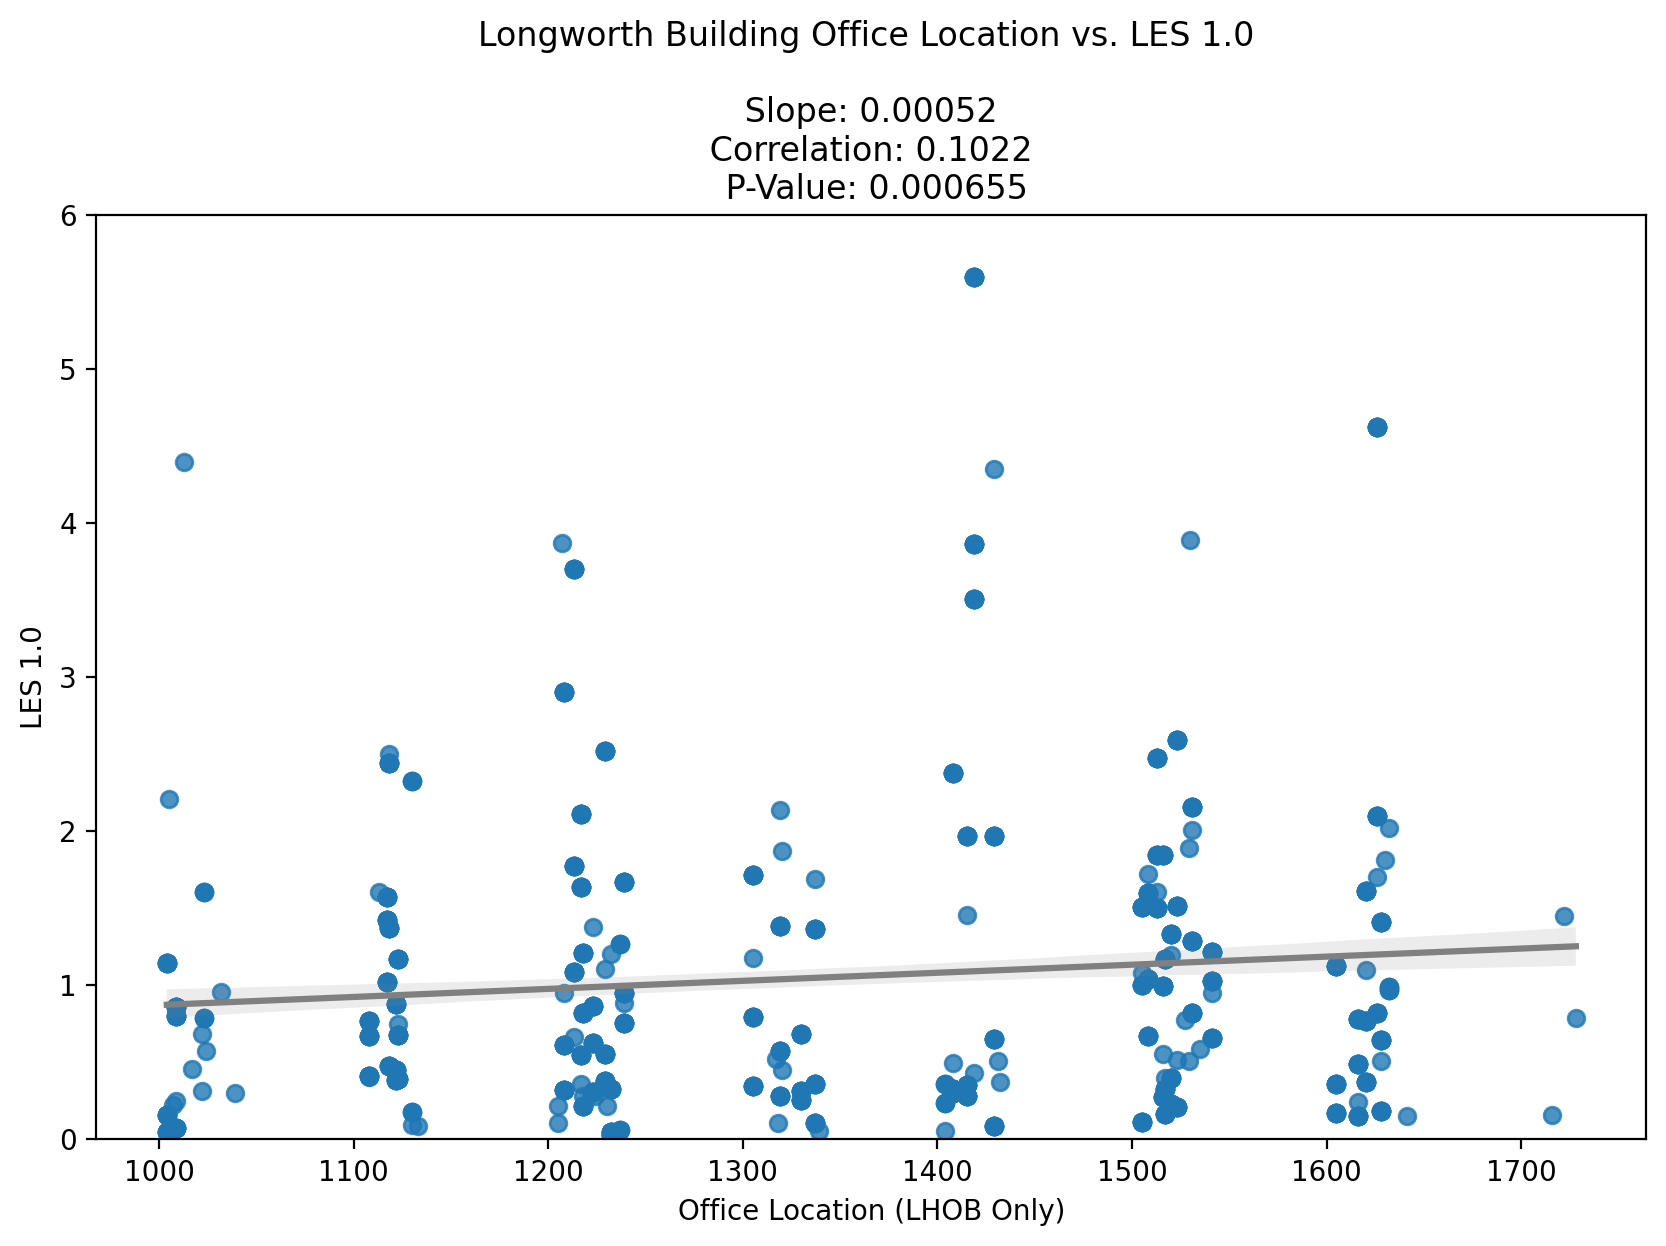

In [14]:
freshman_combined_offices_longworth_only_drop_na = freshman_combined_offices_longworth_only[['Number', 'LES_1.0']].dropna()

slope, intercept = np.polyfit(freshman_combined_offices_longworth_only_drop_na['Number'], freshman_combined_offices_longworth_only_drop_na['LES_1.0'], 1)

#print(f"The slope is: {slope}")


Correlation = freshman_combined_offices_longworth_only['Number'].corr(freshman_combined_offices_longworth_only['LES_1.0'])


clean_df = freshman_combined_offices_longworth_only[['Number', 'LES_1.0']].dropna()

corr_coef, p_value = stats.pearsonr(clean_df['Number'], clean_df['LES_1.0'])

#print(f"P-value: {p_value}")




plt.figure(figsize=(10, 6))
sns.regplot(data=freshman_combined_offices_longworth_only, x='Number', y='LES_1.0', line_kws={"color": "grey"})
plt.title(f"Longworth Building Office Location vs. LES 1.0 \n \n Slope: {round(slope, 5)} \n Correlation: {round(Correlation, 4)} \n P-Value: {round(p_value, 7)}")
plt.xlabel("Office Location (LHOB Only)")
plt.ylabel("LES 1.0");
plt.ylim(0, 6)
plt.savefig("Longworth Building Office Location vs LES.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
freshman_combined_offices_rayburn_only = (
    freshman_combined_offices[freshman_combined_offices["Building"] == "RHOB"]
    .copy()
)

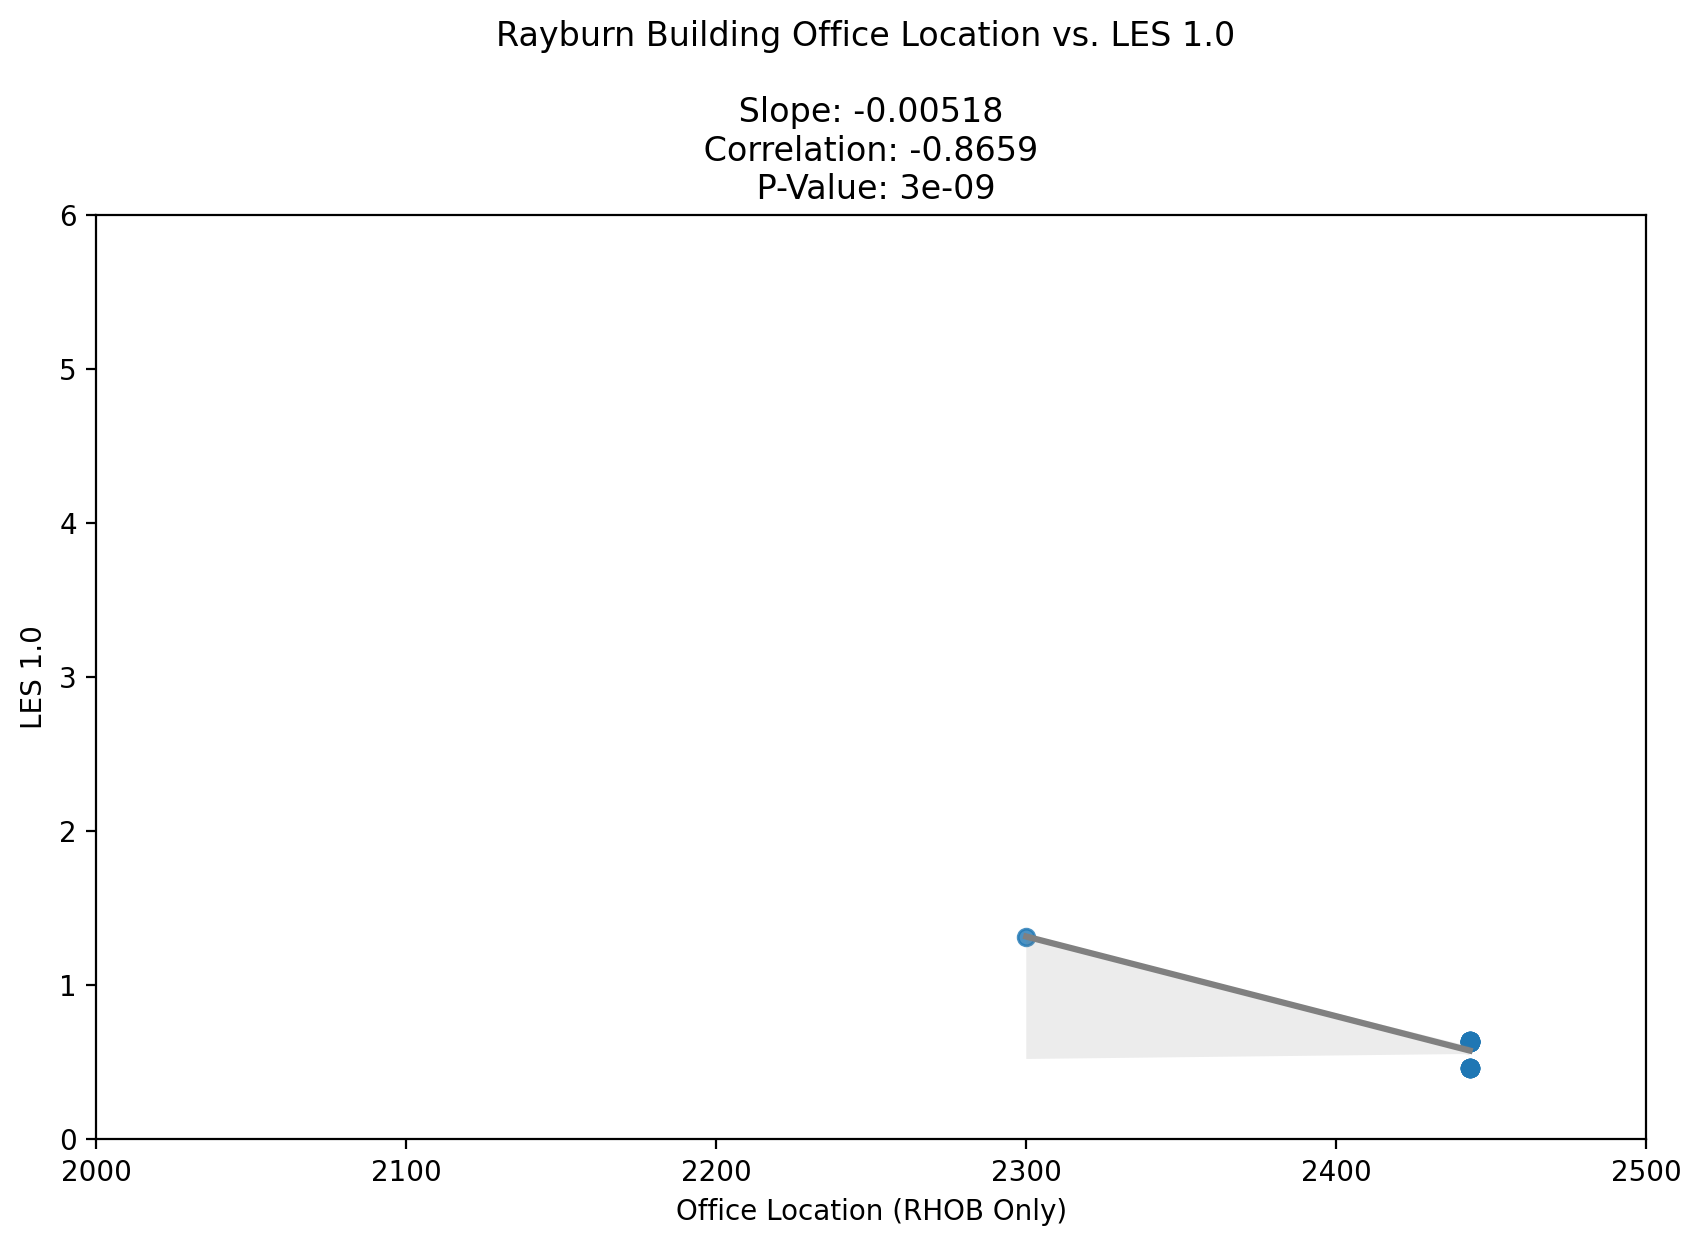

In [16]:
freshman_combined_offices_rayburn_only_drop_na = freshman_combined_offices_rayburn_only[['Number', 'LES_1.0']].dropna()

slope, intercept = np.polyfit(freshman_combined_offices_rayburn_only_drop_na['Number'], freshman_combined_offices_rayburn_only_drop_na['LES_1.0'], 1)

#print(f"The slope is: {slope}")


Correlation = freshman_combined_offices_rayburn_only['Number'].corr(freshman_combined_offices_rayburn_only['LES_1.0'])


clean_df = freshman_combined_offices_rayburn_only[['Number', 'LES_1.0']].dropna()

corr_coef, p_value = stats.pearsonr(clean_df['Number'], clean_df['LES_1.0'])

#print(f"P-value: {p_value}")




plt.figure(figsize=(10, 6))
sns.regplot(data=freshman_combined_offices_rayburn_only, x='Number', y='LES_1.0', line_kws={"color": "grey"})
plt.title(f"Rayburn Building Office Location vs. LES 1.0 \n \n Slope: {round(slope, 5)} \n Correlation: {round(Correlation, 4)} \n P-Value: {round(p_value, 9)}")
plt.xlabel("Office Location (RHOB Only)")
plt.ylabel("LES 1.0");
plt.xlim(2000, 2500)
plt.ylim(0, 6)
plt.savefig("Rayburn Building Office Location vs LES.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
def neighbor_avg(room):
    neighbor_rooms = [room - 2, room - 1, room + 1, room + 2]

    neighbors = combined_offices[
        combined_offices["Number"].isin(neighbor_rooms)
    ]

    return neighbors["Benchmark"].mean()  # ignores NaNs automatically

freshman_combined_offices.loc[:, "neighbor_avg_benchmark"] = (
    freshman_combined_offices["Number"]
    .apply(neighbor_avg)
)

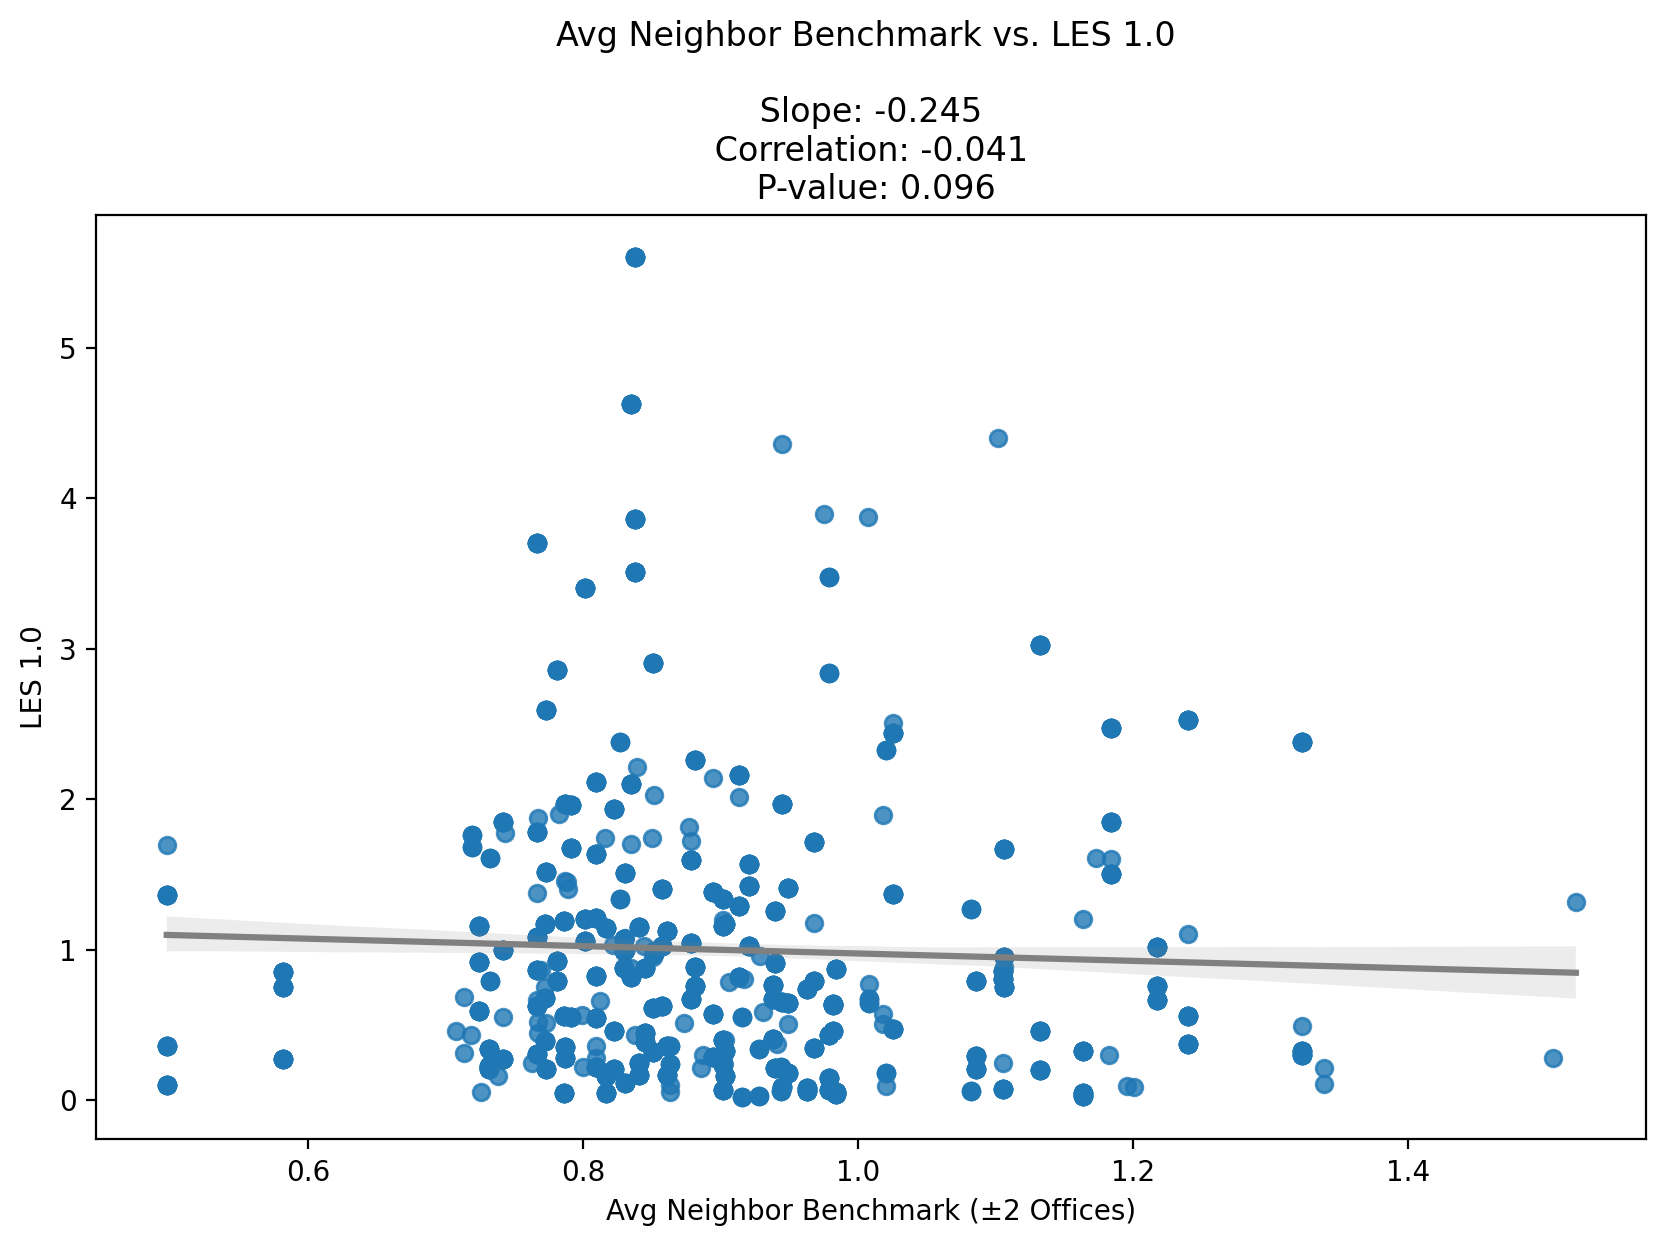

In [18]:
freshman_combined_offices_drop_na = freshman_combined_offices[['neighbor_avg_benchmark', 'LES_1.0']].dropna()

slope, intercept = np.polyfit(freshman_combined_offices_drop_na['neighbor_avg_benchmark'], freshman_combined_offices_drop_na['LES_1.0'], 1)
#chart without trend line


Correlation = freshman_combined_offices['neighbor_avg_benchmark'].corr(freshman_combined_offices['LES_1.0'])

#P-Value
clean_df = freshman_combined_offices[['neighbor_avg_benchmark', 'LES_1.0']].dropna()

corr_coef, p_value = stats.pearsonr(clean_df['neighbor_avg_benchmark'], clean_df['LES_1.0'])
#print(f"P-value: {p_value}")


#freshman_combined_offices.plot.scatter(x="neighbor_avg_benchmark", y="LES_1.0", figsize=(7, 5))
#plt.title("Avg Neighbor Benchmark vs. LES_1.0")
#plt.xlabel("Avg Neighbor Benchmark (±2 Offices)")
#plt.ylabel("LES 1.0");

plt.figure(figsize=(10, 6))
sns.regplot(data=freshman_combined_offices, x="neighbor_avg_benchmark", y="LES_1.0", line_kws={"color": "grey"})
plt.title(f"Avg Neighbor Benchmark vs. LES 1.0 \n \n Slope: {round(slope, 3)} \n Correlation: {round(Correlation, 3)} \n P-value: {round(p_value, 3)}")
plt.xlabel("Avg Neighbor Benchmark (±2 Offices)")
plt.ylabel("LES 1.0");
plt.savefig("Avg Neighbor Benchmark vs LES.png", dpi=300, bbox_inches="tight")
plt.show()

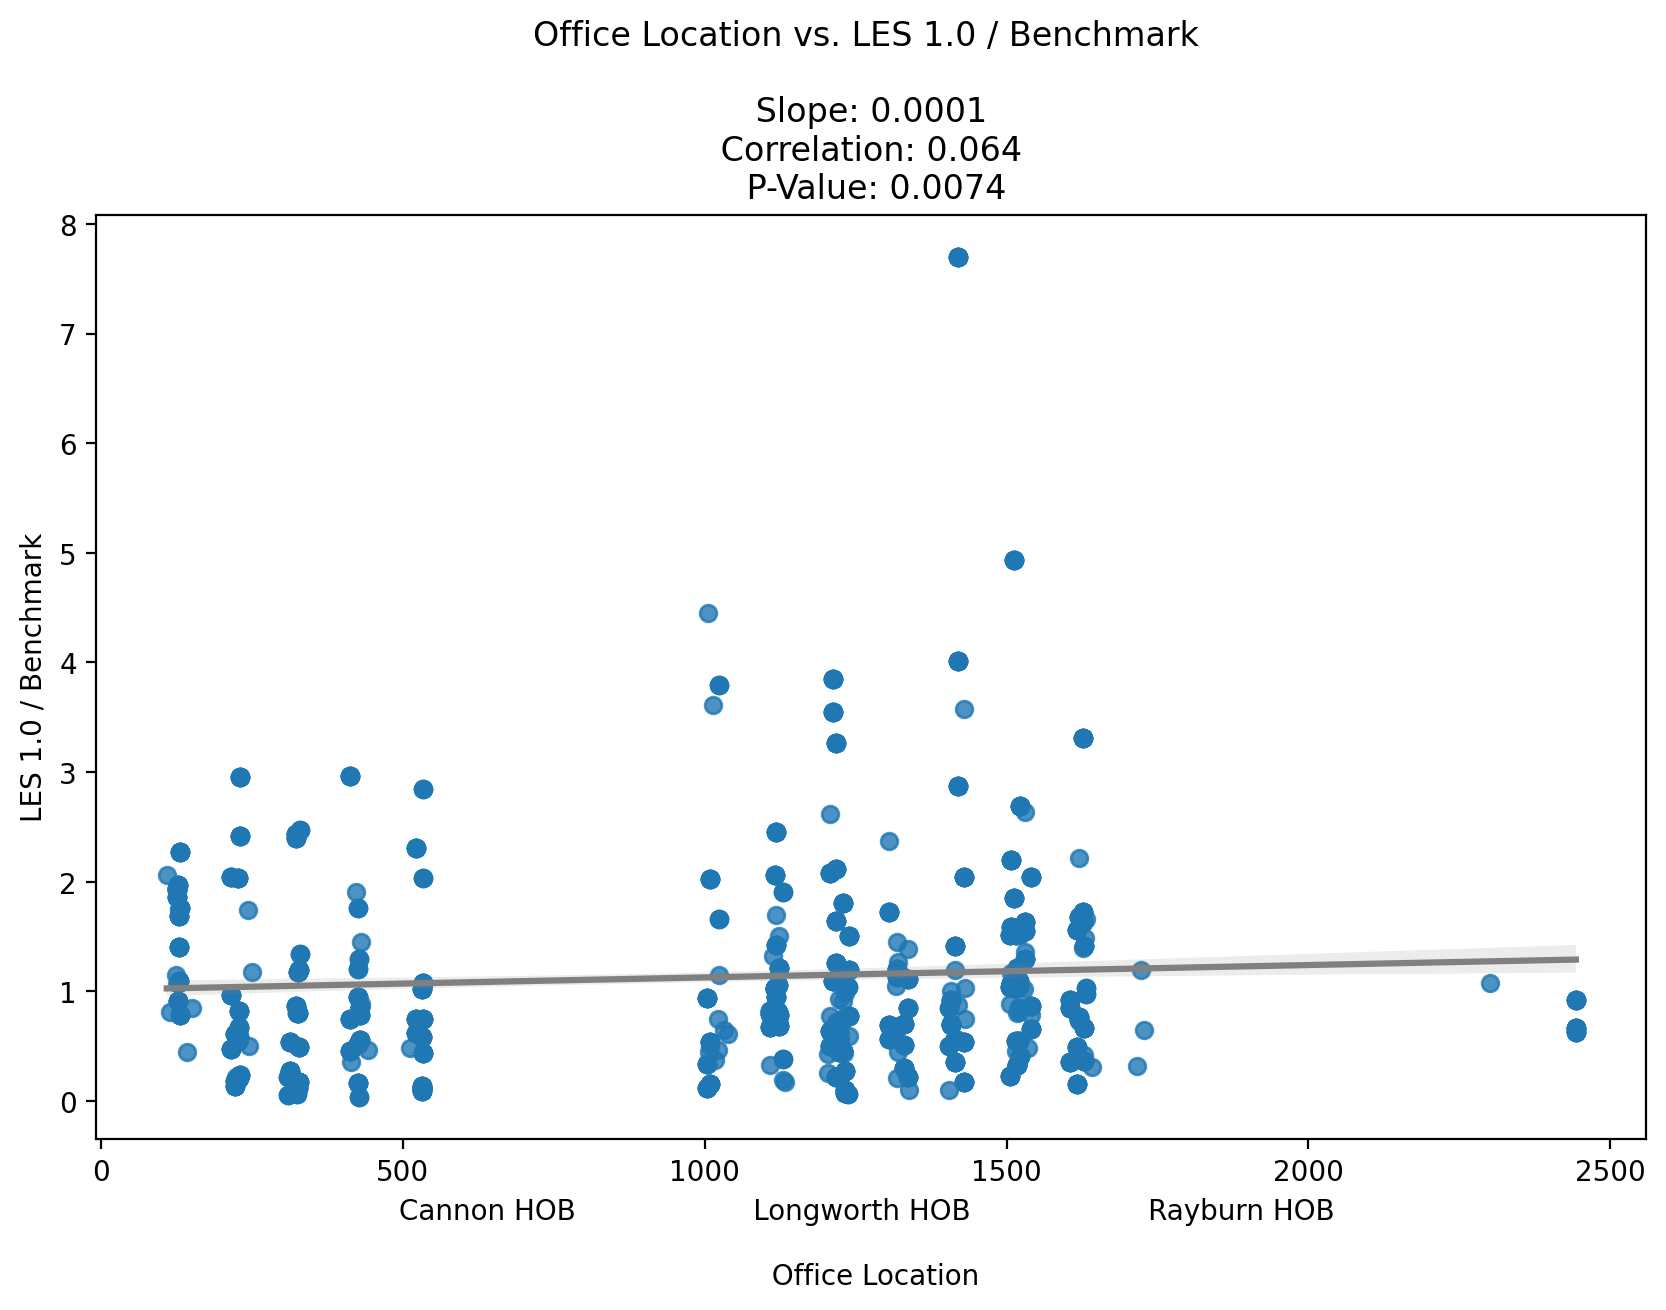

In [19]:
#Scatterchart without trend line

#freshman_combined_offices.plot.scatter(x="Number", y="LES_1.0", figsize=(7, 5))
#plt.title("Office Location vs. LES 1.0")
#plt.xlabel("Office Location")
#plt.ylabel("LES 1.0");
#plt.savefig('my_graph.png', dpi=300, bbox_inches='tight') 

freshman_combined_offices_drop_na = freshman_combined_offices[['Number', 'LES/Benchmark']].dropna()

slope, intercept = np.polyfit(freshman_combined_offices_drop_na['Number'], freshman_combined_offices_drop_na['LES/Benchmark'], 1)

#print(f"The slope is: {slope}")


Correlation = freshman_combined_offices['Number'].corr(freshman_combined_offices['LES/Benchmark'])


clean_df = freshman_combined_offices[['Number', 'LES/Benchmark']].dropna()

corr_coef, p_value = stats.pearsonr(clean_df['Number'], clean_df['LES/Benchmark'])

#print(f"P-value: {p_value}")




plt.figure(figsize=(10, 6))
sns.regplot(data=freshman_combined_offices, x='Number', y='LES/Benchmark', line_kws={"color": "grey"})
plt.title(f"Office Location vs. LES 1.0 / Benchmark \n \n Slope: {round(slope, 4)} \n Correlation: {round(Correlation, 4)} \n P-Value: {round(p_value, 4)}")
plt.xlabel("Cannon HOB                    Longworth HOB                    Rayburn HOB \n \n Office Location")
plt.ylabel("LES 1.0 / Benchmark");
plt.savefig("Office Location vs LES over Benchmark", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
room_col = "Number"
score_col = "LES_1.0"

def neighbor_avg_les(room):
    neighbor_rooms = [room - 2, room - 1, room + 1, room + 2]

    neighbors = combined_offices[
        combined_offices[room_col].isin(neighbor_rooms)
    ]

    return neighbors[score_col].mean()

freshman_combined_offices["neighbor_avg_LES_1.0"] = (
    freshman_combined_offices[room_col]
    .apply(neighbor_avg_les)
)

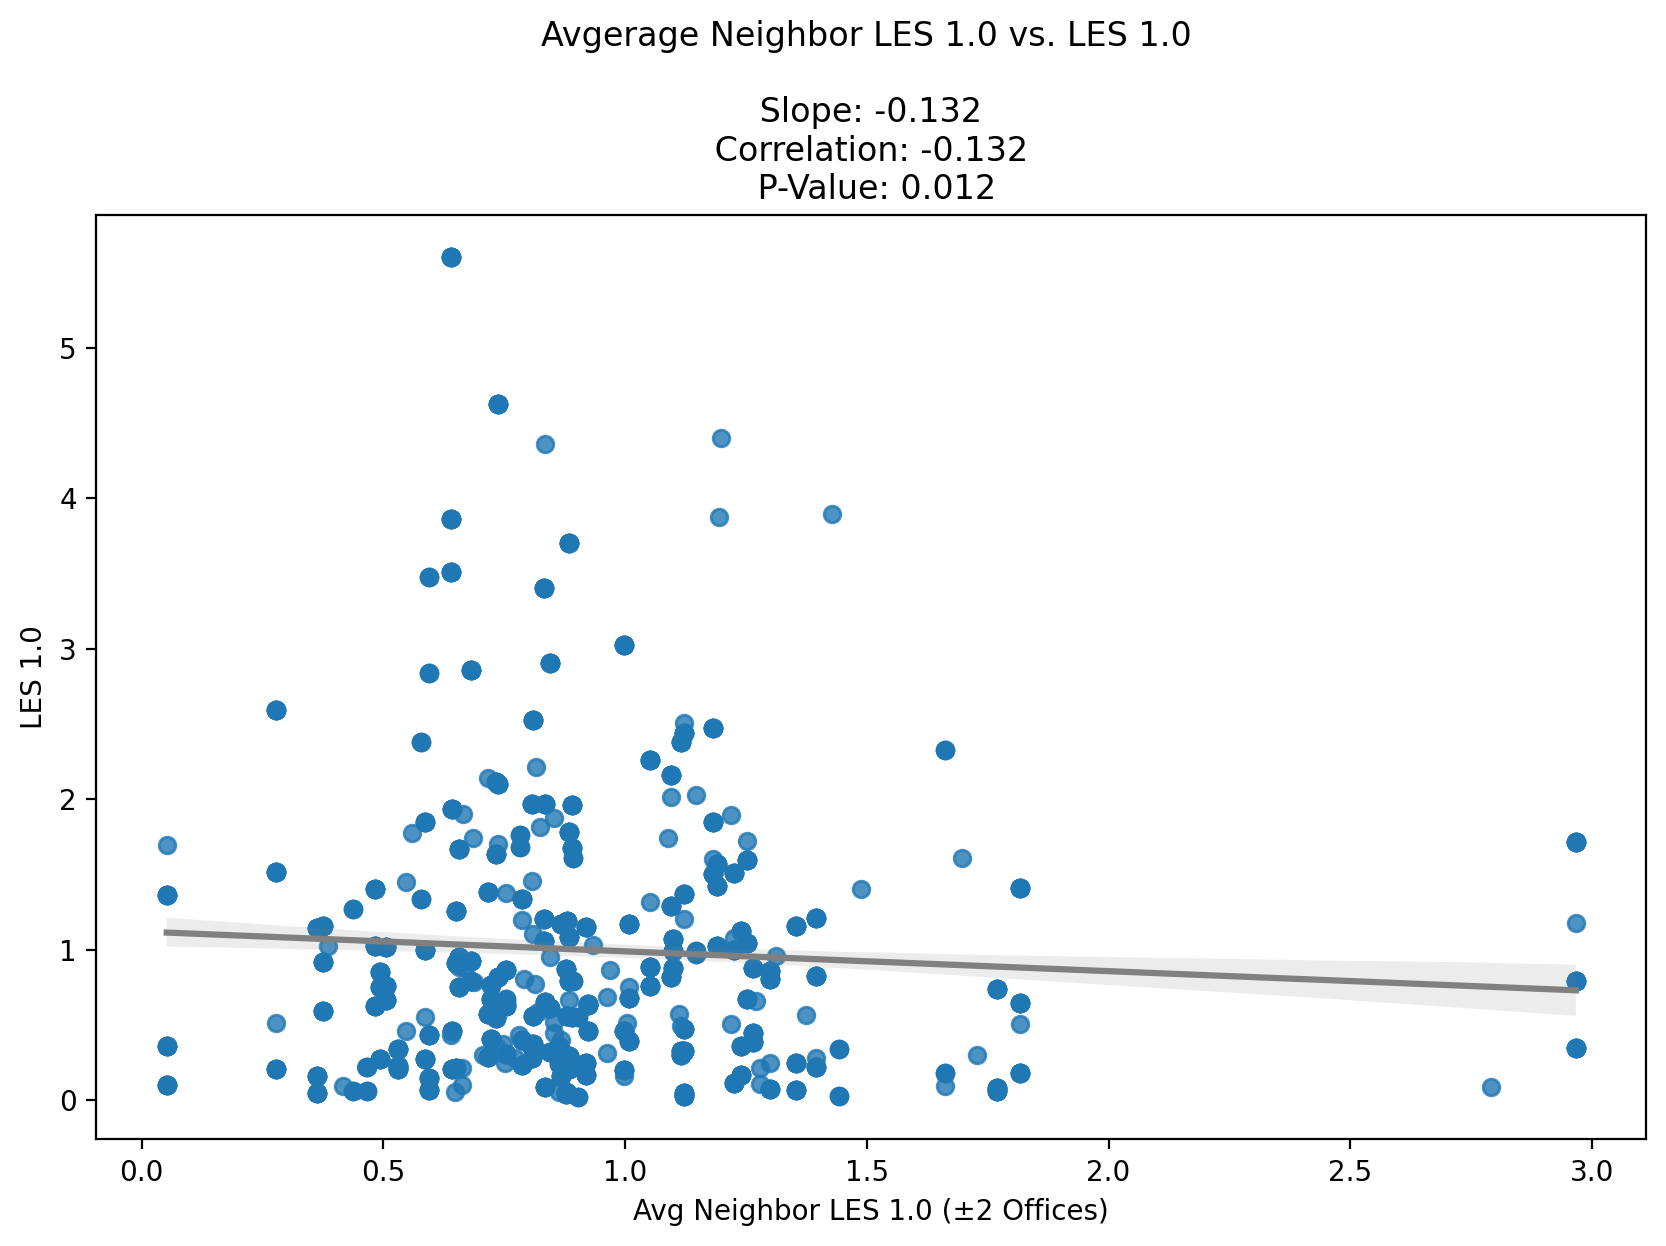

In [21]:
#freshman_combined_offices.plot.scatter(x="neighbor_avg_LES_1.0", y="LES_1.0", figsize=(7, 5))
#plt.title("Avgerage Neighbor LES 1.0 vs. Freshman LES 1.0")
#plt.xlabel("Avg Neighbor LES 1.0 (±2 Offices)")
#plt.ylabel("LES 1.0");

freshman_combined_offices_drop_na = freshman_combined_offices[['neighbor_avg_LES_1.0', 'LES_1.0']].dropna()

slope, intercept = np.polyfit(freshman_combined_offices_drop_na['neighbor_avg_LES_1.0'], freshman_combined_offices_drop_na['LES_1.0'], 1)

#print(f"The slope is: {slope}")

Correlation = freshman_combined_offices['neighbor_avg_LES_1.0'].corr(freshman_combined_offices['LES_1.0'])

#print(Correlation)

clean_df = freshman_combined_offices[['neighbor_avg_LES_1.0', 'LES_1.0']].dropna()

corr_coef, p_value = stats.pearsonr(clean_df['neighbor_avg_LES_1.0'], clean_df['LES_1.0'])

#print(f"P-value: {p_value}")
plt.figure(figsize=(10, 6))

sns.regplot(data=freshman_combined_offices, x="neighbor_avg_LES_1.0", y="LES_1.0", line_kws={"color": "grey"})
plt.title(f"Avgerage Neighbor LES 1.0 vs. LES 1.0 \n \n Slope: {round(slope, 3)} \n Correlation: {round(slope, 3)} \n P-Value: {round(p_value, 3)}")
plt.xlabel("Avg Neighbor LES 1.0 (±2 Offices)")
plt.ylabel("LES 1.0");
plt.savefig("Avgerage Neighbor LES vs. LES.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
print(freshman_combined_offices['Benchmark'].corr(freshman_combined_offices['LES_1.0']))

0.1357159422903479


In [23]:
freshman_combined_offices = freshman_combined_offices.drop(columns='Name')
freshman_combined_offices = freshman_combined_offices.drop(columns='Office Room')
freshman_combined_offices = freshman_combined_offices.drop(columns='Phone')

freshman_combined_offices.sort_values(by='neighbor_avg_benchmark').info()

<class 'pandas.core.frame.DataFrame'>
Index: 1748 entries, 5479 to 14304
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   1748 non-null   object 
 1   District                1748 non-null   object 
 2   Full_Name               1748 non-null   object 
 3   Party                   1748 non-null   object 
 4   Location                1748 non-null   object 
 5   Phone_Number            1748 non-null   object 
 6   Building                1748 non-null   object 
 7   Number                  1748 non-null   float64
 8   First_Name              1748 non-null   object 
 9   Last_Name               1748 non-null   object 
 10  Freshman                1748 non-null   object 
 11  LES_1.0                 1748 non-null   float64
 12  Benchmark               1748 non-null   float64
 13  LES/Benchmark           1748 non-null   float64
 14  neighbor_avg_benchmark  1635 non-null   f

In [24]:
#def distance_to_floor_score(Building: str, Number: int) -> float:

   # Building = str(Building).strip().upper()

   # if Building == "CHOB")
   #     floor  = Number // 100
   #    within = Number % 100
   #     if 1 <= within <= 20:
   #         raw = 2 * (20 - within)
   #     elif 21 <= within <= 41:
   #         raw = 2 * (41 - within)
   #     else:
   #        return np.nan
   #     return raw - _floor_penalty(floor)

  #  elif Building == "LHOB":
    #    adj    = Number - 1000
    #    floor  = adj // 100
    #    within = adj % 100
    #    if 1 <= within <= 36:
    #        raw = 2 * (36 - within)
    #    elif 37 <= within <= 41:
    #        raw = 2 * (36 - ((within - 36) + 6))
    #    else:
    #        return np.nan
    #    return raw - _floor_penalty(floor)

   # elif Building == "RHOB":
     #   adj   = Number - 2000
     #   floor = adj // 100
#        return 9 - floor

  #  else:
  #      return np.nan

In [25]:
#print(distance_to_floor_score)